# Transverse-field Ising model (TFIM)

We consider the one-dimensional transverse-field Ising model
$$
H = -J\sum_{i=1}^{L-1} Z_i Z_{i+1} - g \sum_{i=1}^L X_i .
$$

### Parameter setting:

- **Task:** Thermal state preparation
- **Figure:** Fidelity dynamics
- **System size:** $L=4$ sites
- **Inverse temperature:**  $\beta=1$
- **Gaussian filter width:** $\sigma=2$
- **Coupling strengths:** $\Gamma \in \{1, 0.5, 0.25, 0.1, 0.05, 0.01\}$
- **Bath frequency sampling:** $\omega$ is sampled from the Gaussian distribution associated with the KMS Lindbladian.
- **System operator sampling:** spin operators

In [1]:
import quimb as qu
import numpy as np
import scipy
from scipy.linalg import expm
from scipy.sparse.linalg import expm as sparse_expm
import random 
import matplotlib as mpl 
import matplotlib.pyplot as plt 
from tqdm import tqdm
from hamiltonians import jw_spin_ops
from channels import random_density_orthogonal_to, _expm_from_eigh, _sym_herm, f_gaussian

import warnings
import os
def short_warning(message, category, filename, lineno, line=None):
    return f"{os.path.basename(filename)}:{lineno}: {category.__name__}: {message}\n"
warnings.formatwarning = short_warning

op_kws = {'sparse': True, 'stype': 'coo'}
ikron_kws = {'sparse': True, 'stype': 'coo',
             'coo_build': True, 'ownership': None}

# --- fix all random seeds for reproducibility ---
np.random.seed(66)
random.seed(66)

N=4 #number of sites in the physical model
beta = 1 #inverse temperature
sigma = 2 * beta #width of the Gaussian pulse
Ss = 5 * sigma #simulation time in one iteration
dTime = 0.1 #time step size in one iteration
Nstep = 4000 #number of iterations
dims = [2] * (N+1) #total system+bath dimension
BB = 5 #maximum bath frequency
alpha_list = np.array([1, 0.5, 0.25, 0.1, 0.05, 0.01]) / (sigma**0.5) #different choice of alpha

# spin TFIM model
J = 1
g = 1.2
#TFIM model 
Hamsys = qu.gen.operators.ham_heis(n=N, j=(0, 0, J), b=(g, 0, 0), cyclic=True)
Hamsys = Hamsys.toarray()
rhogibbs = expm(-beta*Hamsys)
rhogibbs = rhogibbs/rhogibbs.trace()
Hamsys = qu.kron(Hamsys, qu.eye(2))
jump_op_array = jw_spin_ops(N) #sample from spin operators

#Initial state preparation: random pure state orthogonal to Gibbs state
rhosys = random_density_orthogonal_to(rhogibbs, approx=True)

#simulation loop
fidelity = np.zeros((Nstep+1,len(alpha_list)))
fidelity[0,:] = np.real(np.trace(scipy.linalg.sqrtm(scipy.linalg.sqrtm(rhogibbs) @ rhosys @ scipy.linalg.sqrtm(rhogibbs)))**2)
rhosys_list = [rhosys.copy() for _ in range(len(alpha_list))]
a_freq = 2 - beta**2 / (4 * sigma**2)
omega_mean = -1 / beta
omega_std = np.sqrt(a_freq) / beta

for i in tqdm(range(Nstep)):

    omega = np.random.normal(loc=omega_mean, scale=omega_std)
    Hambath = -omega * qu.spin_operator('z', **op_kws)
    Hambath = Hambath.toarray()
    rhobath = expm(-beta * Hambath)
    rhobath = rhobath/rhobath.trace()
    Hambath = qu.kron(qu.eye(2**(N), **op_kws), Hambath)
    Hambath = Hambath.toarray()

    k = random.randint(0, N-1)
    # for spin model
    A = random.choice(jump_op_array)
    B = qu.spin_operator('x', **op_kws)+1j*qu.spin_operator('y', **op_kws)
    sign_random = (-1)**(random.randint(0,1))
    interact = sign_random*qu.kron(A,qu.ikron(B, (2,) * 1, 0, **ikron_kws))
    interact += interact.conj().T

    for idx, alpha in enumerate(alpha_list):

        U = np.eye(2**(N+1))

        rho = np.kron(rhosys_list[idx], rhobath)

        # --- build H0 once per i (dense) ---
        H0 = _sym_herm(Hamsys + Hambath)

        # eigendecomp of H0 once → U0_half = exp(-i H0 dt / 2)
        w0, Q0   = np.linalg.eigh(H0)
        U0_half  = _expm_from_eigh(Q0, w0, factor=(-1j * dTime / 2.0))

        # --- build interaction V once per i (dense) ---
        V   = _sym_herm(interact)

        # eigendecomp of V once → later we reuse to get Uv(amp) fast
        wv, Qv = np.linalg.eigh(V.toarray())

        # precompute the pulse values for this i
        nsub  = 2*round(Ss/dTime) + 1
        tgrid = (np.arange(nsub) * dTime) - Ss
        fvals = np.asarray([f_gaussian(t, sigma) for t in tgrid], dtype=float)

        for k in range(nsub):
            amp = fvals[k] * alpha
            Uv = _expm_from_eigh(Qv, wv, factor=(-1j * amp * dTime))
            dU = U0_half @ Uv @ U0_half

            U = U @ dU

        rho = U  @ rho  @ U.conj().T

        rhosys_list[idx] = qu.ptr(rho, dims, list(range(N)))

        fidelity[i+1,idx] = np.real(np.trace(scipy.linalg.sqrtm(scipy.linalg.sqrtm(rhogibbs) @ rhosys_list[idx] @ scipy.linalg.sqrtm(rhogibbs)))**2)


_matfuncs.py:326: RuntimeWarning: divide by zero encountered in matmul
_matfuncs.py:326: RuntimeWarning: overflow encountered in matmul
_matfuncs.py:326: RuntimeWarning: invalid value encountered in matmul
1813613360.py:53: RuntimeWarning: divide by zero encountered in matmul
1813613360.py:53: RuntimeWarning: overflow encountered in matmul
1813613360.py:53: RuntimeWarning: invalid value encountered in matmul
  0%|          | 0/4000 [00:00<?, ?it/s]channels.py:27: RuntimeWarning: divide by zero encountered in matmul
channels.py:27: RuntimeWarning: overflow encountered in matmul
channels.py:27: RuntimeWarning: invalid value encountered in matmul
1813613360.py:104: RuntimeWarning: divide by zero encountered in matmul
1813613360.py:104: RuntimeWarning: overflow encountered in matmul
1813613360.py:104: RuntimeWarning: invalid value encountered in matmul
1813613360.py:106: RuntimeWarning: divide by zero encountered in matmul
1813613360.py:106: RuntimeWarning: overflow encountered in matmul
1

### Plot figures

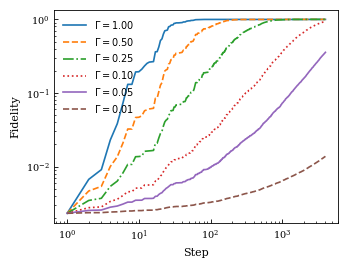

In [2]:
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.6,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.5,
    "ytick.minor.size": 1.5,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
steps = np.arange(Nstep + 1) + 1

fig, ax = plt.subplots(figsize=(3.35, 2.55))

linestyles = ["-", "--", "-.", ":", "-", "--"]

for idx, alpha in enumerate(alpha_list):
    Gamma = alpha * np.sqrt(sigma)
    ax.plot(
        steps,
        fidelity[:, idx],
        linewidth=1.2,
        linestyle=linestyles[idx],
        label=fr"$\Gamma={Gamma:.2f}$"
    )

ax.set_xscale("log", base=10)
ax.set_yscale("log", base=10)

ax.set_xlabel(r"Step")
ax.set_ylabel(r"Fidelity")

ax.legend(loc="upper left", handlelength=2.4)

fig.tight_layout(pad=0.3)
fig.savefig("figures/TFIM_4_dynamics_1_Gaussian.pdf", bbox_inches="tight", dpi=300)
plt.show()